In [7]:
from prismadv.loader import FileLoader
from prismadv.project_manager.manager.base import ProjectManager
from prismadv.utils import get_project_root

In [8]:
dataset_names = ["hr_analytics", "sleep_health", "imdb", "students", "IPL_win_prediction"]
name_map = {
    "hr_analytics": "HR",
    "sleep_health": "Sleep",
    "imdb": "IMDB",
    "students": "Students",
    "IPL_win_prediction": "IPL"
}

In [9]:
import pandas as pd
from typing import Dict, Any


def summarize_dataset(df: pd.DataFrame,
                      name: str = "",
                      cat_max_unique: int = 20,
                      cat_unique_ratio: float = 0.10) -> Dict[str, Any]:
    """General view: dataset-level stats, numeric summary, categorical summary."""
    n_rows, n_cols = df.shape
    n_missing = df.isna().sum().sum()
    pct_missing = (n_missing / (n_rows * n_cols) * 100) if n_rows and n_cols else 0.0
    dup_rows = int(df.duplicated().sum())
    mem_bytes = int(df.memory_usage(deep=True).sum())

    # Type buckets
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    obj_cols = [c for c in df.columns if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c])]
    cat_cols, str_cols = [], []
    for c in obj_cols:
        nunq = df[c].nunique(dropna=True)
        ratio = nunq / n_rows if n_rows else 0.0
        if nunq <= cat_max_unique or ratio <= cat_unique_ratio:
            cat_cols.append(c)
        else:
            str_cols.append(c)

    # Numeric summary
    num_summary = []
    for c in num_cols:
        s = df[c]
        desc = s.describe(percentiles=[0.25, 0.5, 0.75])
        num_summary.append({
            "column": c,
            "count": int(desc["count"]),
            "missing": int(n_rows - desc["count"]),
            "mean": float(desc["mean"]) if "mean" in desc else np.nan,
            "std": float(desc["std"]) if "std" in desc else np.nan,
            "min": float(desc["min"]) if "min" in desc else np.nan,
            "q1": float(desc["25%"]) if "25%" in desc else np.nan,
            "median": float(desc["50%"]) if "50%" in desc else np.nan,
            "q3": float(desc["75%"]) if "75%" in desc else np.nan,
            "max": float(desc["max"]) if "max" in desc else np.nan,
        })

    # Categorical summary
    cat_summary = []
    for c in cat_cols:
        s = df[c]
        vc = s.value_counts(dropna=True)
        top = vc.index[0] if len(vc) else None
        top_n = int(vc.iloc[0]) if len(vc) else 0
        cat_summary.append({
            "column": c,
            "count": int(s.notna().sum()),
            "missing": int(s.isna().sum()),
            "cardinality": int(s.nunique(dropna=True)),
            "mode": top,
            "mode_freq": top_n,
            "mode_pct": float(top_n / n_rows * 100) if n_rows else 0.0,
            "top5": vc.head(5).to_dict()
        })

    # String summary (treated as free text)
    str_summary = []
    for c in str_cols:
        s = df[c].astype("string")
        ln = s.str.len()
        str_summary.append({
            "column": c,
            "count": int(s.notna().sum()),
            "missing": int(s.isna().sum()),
            "unique": int(s.nunique(dropna=True)),
            "unique_ratio": float(s.nunique(dropna=True) / n_rows) if n_rows else 0.0,
            "avg_len": float(ln.mean(skipna=True)) if n_rows else 0.0,
            "min_len": float(ln.min(skipna=True)) if n_rows else 0.0,
            "max_len": float(ln.max(skipna=True)) if n_rows else 0.0,
        })

    # Light correlations for small sets
    corr = df[num_cols].corr(numeric_only=True) if len(num_cols) >= 2 else pd.DataFrame()

    overview = {
        "dataset": name,
        "shape": {"rows": n_rows, "cols": n_cols},
        "missing": {"cells": int(n_missing), "pct": pct_missing},
        "duplicates": dup_rows,
        "memory_bytes": mem_bytes,
        "columns": {
            "numeric": num_cols,
            "categorical": cat_cols,
            "string": str_cols
        },
        "numeric_summary": pd.DataFrame(num_summary).sort_values("missing",
                                                                 ascending=True) if num_summary else pd.DataFrame(),
        "categorical_summary": pd.DataFrame(cat_summary).sort_values(["cardinality", "missing"], ascending=[True,
                                                                                                            True]) if cat_summary else pd.DataFrame(),
        "string_summary": pd.DataFrame(str_summary).sort_values("unique",
                                                                ascending=False) if str_summary else pd.DataFrame(),
        "correlation": corr
    }

    # Drop temporary BP columns from listings
    for bucket in ("numeric", "categorical", "string"):
        overview["columns"][bucket] = [c for c in overview["columns"][bucket] if not c.startswith("_BP_")]
    if "numeric_summary" in overview and not overview["numeric_summary"].empty:
        overview["numeric_summary"] = overview["numeric_summary"][
            ~overview["numeric_summary"]["column"].str.startswith("_BP_")]
    return overview

# --- Usage ---
# hr_view = summarize_dataset(hr_df, name="hr_analytics")
# sleep_view = summarize_dataset(sleep_df, name="sleep_health")
# print_overview(hr_view); print(); print_overview(sleep_view)

In [10]:
dataset_name = "sleep_health"
project_manager = ProjectManager(project_root=get_project_root(), dataset_name=dataset_name)
target_table_name = project_manager.raw_data_info['target_table_name']
target_table_path = project_manager.files_root / f"{target_table_name}.csv"
target_df = FileLoader.load_csv(target_table_path)
overview = summarize_dataset(target_df, name=dataset_name)

In [11]:
rows = []

for dataset_name in dataset_names:
    project_manager = ProjectManager(project_root=get_project_root(), dataset_name=dataset_name)
    target_table_name = project_manager.raw_data_info['target_table_name']
    target_table_path = project_manager.files_root / f"{target_table_name}.csv"
    target_df = FileLoader.load_csv(target_table_path)
    overview = summarize_dataset(target_df, name=dataset_name)

    rows.append({
        "dataset": overview["dataset"],
        "rows": overview["shape"]["rows"],
        "cols": overview["shape"]["cols"],
        "num_numeric": len(overview["columns"]["numeric"]),
        "num_categorical": len(overview["columns"]["categorical"]),
        "num_string": len(overview["columns"]["string"]),
    })

summary_df = pd.DataFrame(rows)
summary_df["ratio_numeric"] = summary_df["num_numeric"] / summary_df["cols"]
summary_df["ratio_categorical"] = summary_df["num_categorical"] / summary_df["cols"]
summary_df["ratio_string"] = summary_df["num_string"] / summary_df["cols"]

# sort: first by numeric ratio, then categorical, then string
summary_df = summary_df.sort_values(
    by=["ratio_numeric", "ratio_categorical", "ratio_string"],
    ascending=[False, False, False]
).reset_index(drop=True)
summary_df

,dataset,rows,cols,num_numeric,num_categorical,num_string,ratio_numeric,ratio_categorical,ratio_string
0,students,4420,37,36,1,0,0.972973,0.027027,0.000000
1,hr_analytics,1470,38,26,11,1,0.684211,0.289474,0.026316
2,sleep_health,374,13,8,5,0,0.615385,0.384615,0.000000
3,IPL_win_prediction,917,20,5,13,2,0.250000,0.650000,0.100000
4,imdb,999,16,4,1,11,0.250000,0.062500,0.687500


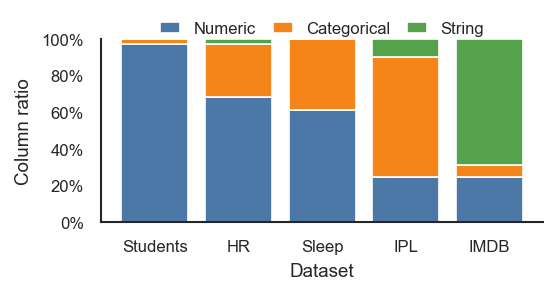

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib as mpl

sns.set_theme(style="white", context="paper", font_scale=1.0)


def plot_composition_stacked(summary_df, save_path=None):
    r = summary_df.copy()
    r["ratio_numeric"] = r["num_numeric"] / r["cols"]
    r["ratio_categorical"] = r["num_categorical"] / r["cols"]
    r["ratio_string"] = r["num_string"] / r["cols"]
    x = np.arange(len(r))

    colors = ["#4C78A8", "#F58518", "#54A24B"]

    fig, ax = plt.subplots(figsize=(3.6, 1.9), dpi=150)

    ax.bar(x, r["ratio_numeric"], label="Numeric", color=colors[0])
    ax.bar(x, r["ratio_categorical"], bottom=r["ratio_numeric"],
           label="Categorical", color=colors[1])
    bottom = r["ratio_numeric"] + r["ratio_categorical"]
    ax.bar(x, r["ratio_string"], bottom=bottom,
           label="String", color=colors[2])

    pretty_labels = [name_map.get(name, name) for name in r["dataset"]]
    ax.set_xticks(x, pretty_labels, rotation=0)
    ax.tick_params(axis="x", labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.set_ylabel("Column ratio", fontsize=9)
    ax.set_xlabel("Dataset", fontsize=9)
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
    ax.grid(False)
    ax.legend(
        frameon=False,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.18),
        ncol=3,
        fontsize=8,
        handlelength=1.2,
        columnspacing=1.0,
    )
    sns.despine(ax=ax)
    plt.tight_layout(pad=0.3)

    if save_path:
        plt.savefig(save_path, format="pdf", bbox_inches="tight")

    plt.show()
plot_composition_stacked(summary_df)
